# Tutorial 4: Two-Dimensional Conversion Functions

`pygid` supports several representations of 2D conversion: GID, Cartesian, polar, and pseudopolar.

Table 1. Conversion functions with description

| Function              | Description                                          | Name of Output Image | Corresponding Matrix Coordinates |
|:----------------------|:----------------------------------------------------|:-------------------|:--------------------------------|
| `det2q_gid()`         | GID coordinates                                     | `img_gid_q`         | `q_xy`, `q_z`                   |
| `det2pol_gid()`       | Polar coordinates for GID experiments              | `img_gid_pol`       | `q_gid_pol`, `ang_gid_pol`      |
| `det2pseudopol_gid()` | Pseudopolar coordinates for GID experiments       | `img_gid_pseudopol` | `q_gid_azimuth`, `q_gid_rad`    |
| `det2q()`             | Cartesian coordinates for transmission experiments | `img_q`             | `q_x`, `q_y`                    |
| `det2pol()`           | Polar coordinates for transmission experiments    | `img_pol`           | `q_pol`, `ang_pol`              |
| `det2pseudopol()`     | Pseudopolar coordinates for transmission experiments | `img_pseudopol`   | `q_azimuth`, `q_rad`            |


**Note:** In this tutorial, only GID and polar conversions are described.
All other conversion functions (`det2pseudopol_gid()`, `det2q()`, `det2pol()`, `det2pseudopol()`) use the same parameters and workflow.


Load datasets from `Zenodo`, and create `params`, `matrix`, and `analysis` instances as described in Tutorials 1–3.

In [1]:
from pygid.datasets import get_dataset

# Download example dataset from Zenodo
try:
    files = get_dataset("tutorial_04")
    poni_path = files["poni"]
    mask_path = files["mask"]
    # several files for batch processing
    data_path = files["data"]
except:
    print("Dataset download skipped on Read the Docs.")

In [2]:
import pygid

# create pygid.ExpParams based on the PONI file
params = pygid.ExpParams(
    poni_path=poni_path,          # path to the PONI file
    mask_path=mask_path,
    ai=0.01,                       # angle of incidence (degrees)
    fliplr=True,
    flipud=True
)

# create pygid.CoordMaps based on pygid.ExpParams
matrix = pygid.CoordMaps(
    params  # pygid.ExpParams
)

# load the data from file
analysis = pygid.Conversion(
    matrix=matrix,                   # pygid.CoordMaps
    path=data_path,                  # path to the raw data file
    dataset='/entry_0000/ESRF-ID10/eiger4m/data'  # dataset path
)
print(f"raw data shape {analysis.img_raw.shape}")

raw data shape (13, 2162, 2068)


---
#### **Minimal Code Example**


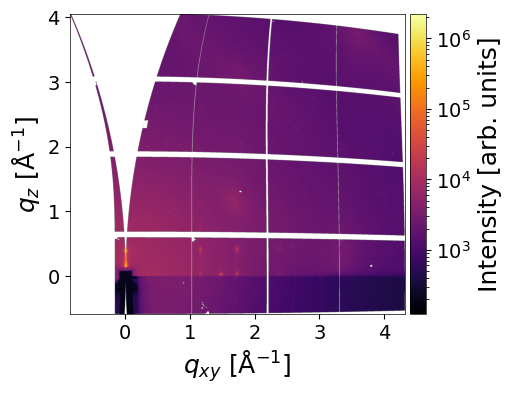

In [9]:
analysis.det2q_gid(
    frame_num=7,                   # frames to convert; None = all images
    plot_result=True
)

---
#### Parameters (for all remapping functions)

Main parameters:
- `frame_num` – index or list of indiced of loaded frames to convert (not the frame number in file). If `None`, all loaded images are converted.
- `return_result` – if `True`, returns converted image and axes arrays. Default is `False`.
- `interp_type` – interpolation method for remapping (`"INTER_LINEAR"`, `"INTER_NEAREST"`, etc.). Default: `"INTER_LINEAR"`.
- `multiprocessing` – flag to enable multiprocessing. If `None`, uses the default defined in the `Conversion` class.
- `q_xy_range` - q_xy range (tuple, in Å⁻¹) for det2q_gid() function
- `q_z_range` - q_z range (tuple, in Å⁻¹) for det2q_gid() function
- `radial_range` - radial range range (tuple, in Å⁻¹) for det2pol_gid() function
- `angular_range` - angular range range (tuple, in degrees) for det2pol_gid() function

Saving parameters:
- `save_result` – whether to save the result as an HDF5 file in NXsas format.
- `path_to_save` – output path for the HDF5 result file.
- `h5_group` – name of the NXentry dataset within the HDF5 file.
- `overwrite_file` – if `True`, overwrites existing HDF5 file. Default is `True`.
- `overwrite_group` – if `True`, overwrites existing NXentry group. Default is `True`.
- `exp_metadata` – `ExpMetadata` instance containing experimental information (see [Tutorial 6](tutorial_06_metadata_curation.ipynb)).
- `smpl_metadata` – `SampleMetadata` instance containing sample information (see  [Tutorial 6](tutorial_06_metadata_curation.ipynb)).

Plotting parameters:
- `plot_result` – whether to plot the remapped image.
- `clims` – tuple `(vmin, vmax)` defining color scale limits.
- `xlim`, `ylim` – tuples defining X and Y axis limits for the plot.
- `save_fig` – whether to save the plotted image to a file.
- `path_to_save_fig` – path to save the plot (e.g. `.png`, `.tiff`).


#### Reciprocal Space Conversion (GID Geometry)


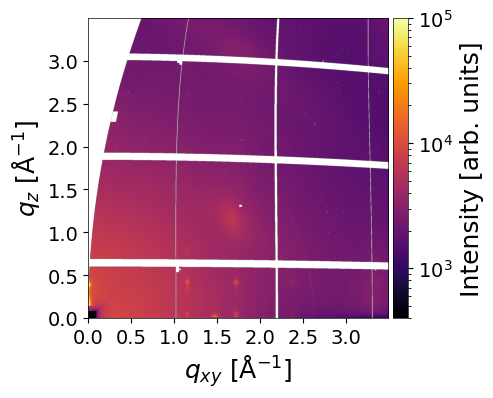

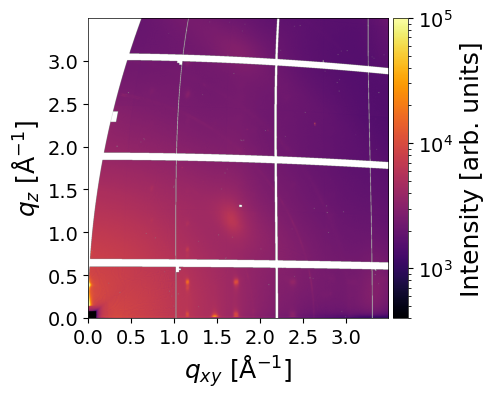

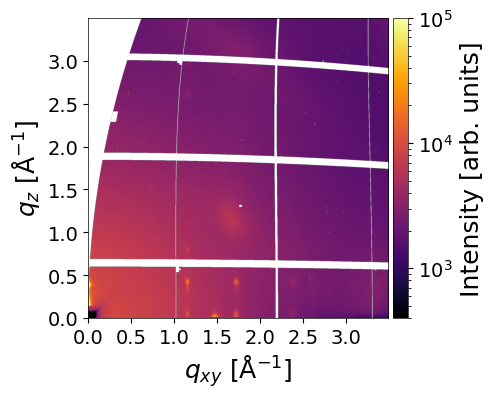

x-axis shape (1507,)
y-axis shape (1507,)
length of images and thier shape (3, (1507, 1507))


In [23]:
q_xy, q_z, img = analysis.det2q_gid(
    frame_num=[5,6,7],                   # frames to convert; None = all images
    plot_result=True,
    return_result=True,
    clims=(4e2,1e5),
    q_xy_range = (0,3.5),
    q_z_range = (0,3.5),
)

print(f"x-axis shape {q_xy.shape}")
print(f"y-axis shape {q_z.shape}")
print(f"length of images and their shape {len(img), img[0].shape}")

#### Polar Conversion (GID Geometry)

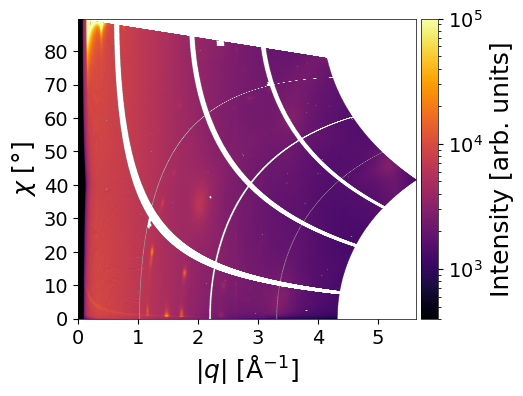

In [14]:
q_xy, q_z, img = analysis.det2pol_gid(
    frame_num=7,                   # frames to convert; None = all images
    plot_result=True,
    return_result=True,
    clims=(4e2,1e5),
    angular_range = (0,90)  #
)

### Plotting After Conversion

The results of the conversion can be visualized immediately after processing by calling plot_result.
The method optionally returns the numerical data arrays and supports plotting of selected frames.


INFO - Saved figure in D:\PhD\mlgid\pygid\docs\tutorials\graph_0000.tiff


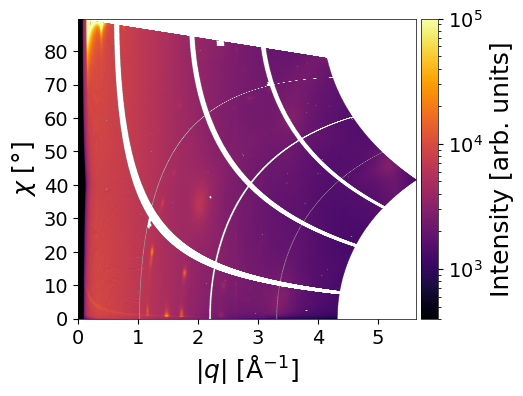

In [18]:
x, y, img = analysis.plot_result(
    return_result=True,                 # return data arrays
    frame_num=0,                        # frames to convert (int or list); None = all images
    plot_result=True,                   # plot result
    clims=(4e2,1e5),                    # intensity limits
    save_fig=True,                      # save plot flag
    path_to_save_fig="graph.tiff",      # save plot path
)


NOTE: Plot parameters can be changed using `pygid.set_plot_defaults` function as shown in [Tutorial 3](tutorial_03_raw_data_loading.ipynb)

### Saving of the Result

Converted data can be saved as an **NXsas** file (NeXus / HDF5) with a dedicated internal structure.

The output file can store:
- multiple images in a **single entry**, or
- images in **different entries** within the same file.

To save results from **multiple `pygid.Conversion` instances into one file**, set
`overwrite_file = False`.
In this case, all images **must have the same shape** (same q-range and resolution).
If the shape differs, a **new entry is created automatically**.

The saved file also contains:
- PONI file information
- full details of the conversion parameters

For viewing and inspecting the resulting NeXus files, **`silx view`** is recommended.

Experimental and sample metadata can also be stored in the file; this is described in  [Tutorial 6](tutorial_06_metadata_curation.ipynb).


In [26]:
q_xy, q_z, img = analysis.det2q_gid(
    frame_num=None,
    plot_result=False,
    return_result=True,
    clims=(4e2,1e5),
    q_xy_range=(0,3.5),
    q_z_range=(0,3.5),
    save_result=True,
    path_to_save='result.h5'
)

print(f"x-axis shape {q_xy.shape}")
print(f"y-axis shape {q_z.shape}")
print(f"length of images and their shape {len(img), img[0].shape}")

INFO - Saved in D:\PhD\mlgid\pygid\docs\tutorials\result.h5 in group entry_0000


x-axis shape (1507,)
y-axis shape (1507,)
length of images and their shape (13, (1507, 1507))


13 converted images have been saved in  'result.h5' as a single dataset

### Modifying and Saving Data After Conversion

Converted data can be modified in memory after the conversion step and before saving. This allows for post-processing adjustments prior to writing the final HDF5 output.

In [27]:
# Run conversion without saving
analysis.det2q_gid(save_result=False)

# Modify converted image data
# (must remain a list of 2D NumPy arrays)
analysis.img_gid_q[0] /= 2

# Save results to HDF5
pygid.DataSaver(
    analysis,                    # pygid.Conversion instance
    path_to_save='result.h5',    # path to save
    overwrite_file=True,         # Whether to overwrite an existing HDF5 file
    overwrite_group = True,      # Whether to overwrite an existing HDF5 entry
    h5_group = 'entry_0000',          # The specific group in the HDF5 file
)

INFO - Saved in D:\PhD\mlgid\pygid\docs\tutorials\result.h5 in group entry_0000


NOTE: a new conversion overwrites the result of previous conversion in memory